In [1]:
DRIVE_ENABLED = True
TRAINING = True
PREDICTION = True

In [2]:
if DRIVE_ENABLED:
  from google.colab import drive
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# !sh ./unet-setup.sh
!git clone https://github.com/clemkoa/u-net

fatal: destination path 'u-net' already exists and is not an empty directory.


In [4]:
import importlib
import torch.nn as nn
# unet = importlib.import_module("u-net.unet")

# Pass the __init__. Import unet.py directly.
unet = importlib.import_module("u-net.unet.unet")

In [5]:
# Override u-net class

class UNet(nn.Module):
    def __init__(self, dimensions=2, in_channels=1):
        super(UNet, self).__init__()
        self.conv1 = unet.DoubleConv(in_channels, 64)
        self.down1 = unet.DownLayer(64, 128)
        self.down2 = unet.DownLayer(128, 256)
        self.down3 = unet.DownLayer(256, 512)
        self.down4 = unet.DownLayer(512, 1024)
        self.up1 = unet.UpLayer(1024, 512)
        self.up2 = unet.UpLayer(512, 256)
        self.up3 = unet.UpLayer(256, 128)
        self.up4 = unet.UpLayer(128, 64)
        self.last_conv = nn.Conv2d(64, dimensions, 1)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x1_up = self.up1(x4, x5)
        x2_up = self.up2(x3, x1_up)
        x3_up = self.up3(x2, x2_up)
        x4_up = self.up4(x1, x3_up)
        output = self.last_conv(x4_up)
        return output


In [6]:
model = UNet(22, 3)


In [7]:
import torch
x = torch.rand(1, 3, 512, 512)
out = model(x)

In [8]:
out.shape

torch.Size([1, 22, 512, 512])

## Train

In [9]:
from os import path
from sys import stderr
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets

from PIL import Image
import matplotlib.pyplot as plt

In [10]:
%matplotlib inline

In [11]:
DATA_PATH = "data"
MODEL_DIR_PATH = Path("model")
MODEL_DIR_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR_PATH / "unet.pth"
CHECKPOINT_INTERVAL = 10
EPOCHS = 100
SHUFFLE_DATA_LOADER = False

In [12]:
if DRIVE_ENABLED:
    DATA_PATH = "/content/drive/MyDrive/machine-learning/data"
    MODEL_DIR_PATH = Path("/content/drive/MyDrive/machine-learning/model")
    MODEL_DIR_PATH.mkdir(parents=True, exist_ok=True)
    MODEL_PATH = MODEL_DIR_PATH / "unet.pth"

In [13]:
device = "cpu"
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using device: {device}")

Using device: cuda


In [14]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    # transforms.Grayscale(3)
])
dataset = datasets.VOCSegmentation(
    DATA_PATH,
    year="2007",
    download=True,
    image_set="train",
    transform=transform,
    target_transform=transform
)

In [15]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=SHUFFLE_DATA_LOADER,
)

model = UNet(dimensions=22, in_channels=3).to(device)

if path.isfile(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"Model loaded from {MODEL_PATH}")
else:
    print(f"WARNING: Model file {MODEL_PATH} does not exist.", file=stderr)

optimizer = optim.RMSprop(model.parameters(), lr=1e-8, momentum=.9)
criterion = nn.CrossEntropyLoss()

if TRAINING:
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        losses = []
        for i, batch in enumerate(dataloader):
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.type(torch.LongTensor).to(device)

            if inputs.shape[0] < 2:
                continue

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets.squeeze())
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
        print(sum(losses) / len(losses))
        if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"Model saved to {MODEL_PATH}")
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Final model saved to {MODEL_PATH}")

Model loaded from /content/drive/MyDrive/machine-learning/model/unet.pth
Epoch 1/100
2.540084169461177
Epoch 2/100
2.5316288517071652
Epoch 3/100
2.5282918948393602
Epoch 4/100
2.525179175230173
Epoch 5/100
2.5221683979034424
Epoch 6/100
2.519303117807095
Epoch 7/100
2.516552922817377
Epoch 8/100
2.5138138097066145
Epoch 9/100
2.5111219653716454
Epoch 10/100
2.508457275537344
Model saved to /content/drive/MyDrive/machine-learning/model/unet.pth
Epoch 11/100
2.505825395767505
Epoch 12/100
2.5032772696935215
Epoch 13/100
2.5007895552195034
Epoch 14/100
2.4982778407060184
Epoch 15/100
2.4957927075716166
Epoch 16/100
2.4932583685104666
Epoch 17/100
2.49079302411813
Epoch 18/100
2.488446043087886
Epoch 19/100
2.486145535340676
Epoch 20/100
2.483817451275312
Model saved to /content/drive/MyDrive/machine-learning/model/unet.pth
Epoch 21/100
2.481524511025502
Epoch 22/100
2.47922362272556
Epoch 23/100
2.476949221812762
Epoch 24/100
2.4747740740959463
Epoch 25/100
2.472641495557932
Epoch 26/100

## Predict

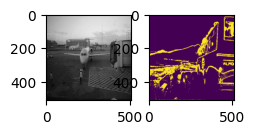

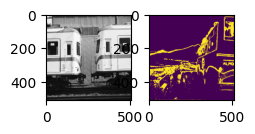

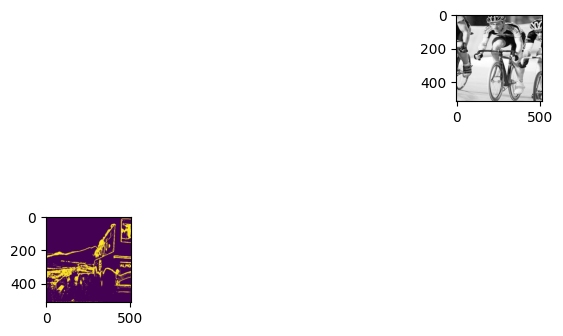

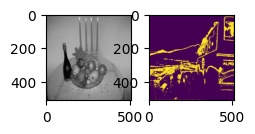

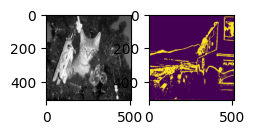

In [16]:
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint)
model.eval()

if PREDICTION:
    for i, batch in enumerate(dataloader):
        if i >= 5:
          break
        inputs, _ = batch
        inputs = inputs.to(device)
        output = model(inputs).detach()
        inputs_array = inputs.squeeze().detach().cpu().numpy()
        outputs_array = outputs.argmax(dim=1)
        outputs_array = torch.where(outputs_array > 0, 255, 0)

        inputs_img = Image.fromarray(inputs_array[0, 0, ] * 255)
        plt.subplot(2, 5, 2 * i + 1)
        plt.imshow(inputs_img)
        outputs_img = Image.fromarray(outputs_array[0, ].squeeze().cpu().numpy().astype(dtype=np.uint16))
        plt.subplot(2, 5, 2 * i + 2)
        plt.imshow(outputs_img)
        plt.show()